# 🌦️ Weather Data Analysis of India

### Problem Statement
The project analyzes multi-year historical climate data across `24 major cities` representing all geographic regions of India to capture nationwide weather variability. Using multi-variable meteorological data, the study `identifies long-term climate trends, regional seasonal patterns, and extreme weather events such as heatwaves and heavy rainfall`. The project also examines `interactions between atmospheric, hydrological, and land-surface variables to understand climate system behavior`. The goal is to build data-driven insights and risk indicators to support climate monitoring and environmental analysis.

# 🇮🇳 Cities Covered — Grouped by Region

## 🧭 North India
- Delhi
- Srinagar
- Ladakh
- Amritsar
- Manali
- Nainital
- Lucknow

## 🌅 East India
- Patna
- Kolkata (Calcutta)

## 🌧️ Northeast India
- Guwahati
- Agartala
- Geku

## 🌵 West India
- Ahmedabad
- Jaisalmer
- Mumbai

## 🌾 Central India
- Kota
- Jabalpur
- Nagpur

## 🌴 South India
- Chennai
- Bengaluru
- Hyderabad
- Visakhapatnam
- Udupi
- Thiruvananthapuram

---

### 📌 Notes
- Cities are grouped based on broad geographic regions used in climatology and weather analysis.
- Some locations (e.g., **Ladakh**) represent larger geographic regions rather than a single city.
- Kolkata and Calcutta refer to the same city; the modern name **Kolkata** is used here.

# 🪨 Column Descriptions

| Variable | Unit | Description |
|---|---|---|
| **time** | ISO8601 (date) | Date of the observation (daily timestamp). |
| **weather_code** | WMO code | The most severe weather condition on a given day |
| **temperature_2m_max** | °C | Maximum daily air temperature at 2 meters above ground |
| **temperature_2m_min** | °C | Minimum daily air temperature at 2 meters above ground |
| **temperature_2m_mean** | °C | Mean daily air temperature at 2 meters above ground (daily average). |
| **apparent_temperature_max** | °C | Maximum daily apparent (feels-like) temperature |
| **apparent_temperature_min** | °C | Minimum daily apparent (feels-like) temperature |
| **sunshine_duration** | seconds | Number of seconds of sunshine per day (direct irradiance > 120 W/m², WMO definition). This is typically less than daylight duration due to dawn and dusk. |
| **daylight_duration** | seconds | Total number of daylight seconds per day |
| **sunrise** | ISO8601 | Sunrise time |
| **sunset** | ISO8601 | Sunset time |
| **precipitation_sum** | mm | Total daily precipitation (rain, showers, and snowfall) |
| **rain_sum** | mm | Total daily rainfall |
| **snowfall_sum** | cm | Total daily snowfall |
| **precipitation_hours** | hours | Number of hours with precipitation |
| **shortwave_radiation_sum** | MJ/m² | Total daily incoming shortwave solar radiation |
| **wind_direction_10m_dominant** | ° | Dominant wind direction |
| **wind_speed_10m_max** | km/h | Maximum wind speed at 10 meters above ground |
| **wind_speed_10m_min** | km/h | Minimum daily wind speed at 10 meters above ground |
| **wind_speed_10m_mean** | km/h | Mean daily wind speed at 10 meters above ground |
| **et0_fao_evapotranspiration** | mm | Daily reference evapotranspiration (ET₀) for a well-watered grass field (FAO standard) |
| **cloud_cover_max** | % | Maximum total cloud cover during the day (0–100%). |
| **cloud_cover_min** | % | Minimum total cloud cover during the day (0–100%). |
| **cloud_cover_mean** | % | Mean daily total cloud cover (0–100%). |
| **soil_moisture_0_to_100cm_mean** | m³/m³ | Mean volumetric soil water content averaged from surface to 100 cm depth. |
| **soil_temperature_0_to_100cm_mean** | °C | Mean soil temperature averaged from surface to 100 cm depth. |
| **dew_point_2m_min** | °C | Minimum daily dew point temperature at 2 meters above ground. |
| **dew_point_2m_max** | °C | Maximum daily dew point temperature at 2 meters above ground. |
| **dew_point_2m_mean** | °C | Mean daily dew point temperature at 2 meters above ground. |
| **wet_bulb_temperature_2m_min** | °C | Minimum daily wet-bulb temperature at 2 meters above ground. |
| **wet_bulb_temperature_2m_max** | °C | Maximum daily wet-bulb temperature at 2 meters above ground. |
| **wet_bulb_temperature_2m_mean** | °C | Mean daily wet-bulb temperature at 2 meters above ground. |
| **relative_humidity_2m_min** | % | Minimum daily relative humidity at 2 meters above ground. |
| **relative_humidity_2m_max** | % | Maximum daily relative humidity at 2 meters above ground. |
| **relative_humidity_2m_mean** | % | Mean daily relative humidity at 2 meters above ground. |
| **surface_pressure_min** | hPa | Minimum daily surface air pressure. |
| **surface_pressure_max** | hPa | Maximum daily surface air pressure. |
| **pressure_msl_min** | hPa | Minimum daily mean sea-level pressure (MSL). |
| **pressure_msl_max** | hPa | Maximum daily mean sea-level pressure (MSL). |
| **pressure_msl_mean** | hPa | Mean daily mean sea-level pressure (MSL). |
| **latitude** | decimal degrees | Latitude of the location. |
| **longitude** | decimal degrees | Longitude of the location. |
| **location_id** | — | Unique identifier assigned to each location in the dataset. |

---

## 📌 Notes
- Temperature values are measured at **2 meters** above ground level.  
- Wind values are measured at **10 meters** above ground level.  
- Times are provided in **ISO 8601** format.  
- Cloud cover is expressed as **percentage of sky covered by clouds (0–100%)**.  
- Soil variables represent **layer-averaged values from 0–100 cm depth**.

In [1]:
# Library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import plotly.express as px

### Combine the 3 dataframes into one and export as a single file

In [2]:
# df_part1= pd.read_csv(r'weather_data_7_locations.csv')
# df_part2= pd.read_csv(r'weather_data_8_locations.csv')
# df_part3= pd.read_csv(r'weather_data_9_locations.csv')


# On viewing the csv, we find that df_part1 is of the format yyyy-mm-dd and df_part2 and df_part3 are both of the format dd-mm-yyyy.
# So we convert df_part1 to match the format of the other two and the merge them into single dataset

# df_part1["time"] = pd.to_datetime(df_part1["time"], format="%Y-%m-%d")
# df_part1["time"] = df_part1["time"].dt.strftime("%d-%m-%Y")                 # convert format to dd-mm-yyyy
# df_part1.head()

,time,weather_code,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,sunshine_duration,daylight_duration,sunrise,sunset,...,relative_humidity_2m_mean,soil_temperature_0_to_100cm_mean,wind_speed_10m_min,wind_speed_10m_mean,wet_bulb_temperature_2m_min,wet_bulb_temperature_2m_max,wet_bulb_temperature_2m_mean,latitude,longitude,location_id
0,01-01-2018,0,24.4,11.4,23.5,10.1,35208.99,38161.03,2018-01-01T07:12,2018-01-01T17:48,...,56,21.0,2.4,7.0,8.9,15.4,11.6,25.202108,75.80994,1
1,02-01-2018,0,22.8,8.6,20.5,7.1,35233.59,38183.40,2018-01-02T07:12,2018-01-02T17:48,...,56,20.8,3.2,5.9,7.5,12.4,9.8,25.202108,75.80994,1
2,03-01-2018,0,22.9,10.3,20.4,8.2,35260.27,38207.68,2018-01-03T07:12,2018-01-03T17:49,...,55,20.5,1.6,6.0,7.6,12.0,9.7,25.202108,75.80994,1
3,04-01-2018,0,24.4,8.1,22.0,5.7,35289.14,38233.86,2018-01-04T07:12,2018-01-04T17:50,...,56,20.3,2.6,7.6,7.0,12.9,10.1,25.202108,75.80994,1
4,05-01-2018,0,24.0,9.9,22.4,8.7,35320.67,38262.24,2018-01-05T07:13,2018-01-05T17:50,...,58,20.2,1.3,5.2,8.5,14.3,11.2,25.202108,75.80994,1


In [3]:
# Now we can merge all 3 df_parts into one single dataset 
combined_df= pd.concat([df_part1, df_part2, df_part3], ignore_index= True)
print("The dataset has been combined into a single dataset with", combined_df.shape[0], "rows")

# export the combined dataset
# combined_df.to_csv('complete_weather_data.csv', index= False)

The dataset has been combined into a single dataset with 80000 rows


# ▶️ Import combined dataset

In [4]:
# Import the complete combined dataset
df= pd.read_csv(r'complete_weather_data.csv')
original_df= df.copy()
df.head(10)

,time,weather_code,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,sunshine_duration,daylight_duration,sunrise,sunset,...,relative_humidity_2m_mean,soil_temperature_0_to_100cm_mean,wind_speed_10m_min,wind_speed_10m_mean,wet_bulb_temperature_2m_min,wet_bulb_temperature_2m_max,wet_bulb_temperature_2m_mean,latitude,longitude,location_id
0,01-01-2018,0,24.4,11.4,23.5,10.1,35208.99,38161.03,2018-01-01T07:12,2018-01-01T17:48,...,56.0,21.0,2.4,7.0,8.9,15.4,11.6,25.202108,75.80994,1
1,02-01-2018,0,22.8,8.6,20.5,7.1,35233.59,38183.40,2018-01-02T07:12,2018-01-02T17:48,...,56.0,20.8,3.2,5.9,7.5,12.4,9.8,25.202108,75.80994,1
2,03-01-2018,0,22.9,10.3,20.4,8.2,35260.27,38207.68,2018-01-03T07:12,2018-01-03T17:49,...,55.0,20.5,1.6,6.0,7.6,12.0,9.7,25.202108,75.80994,1
3,04-01-2018,0,24.4,8.1,22.0,5.7,35289.14,38233.86,2018-01-04T07:12,2018-01-04T17:50,...,56.0,20.3,2.6,7.6,7.0,12.9,10.1,25.202108,75.80994,1
4,05-01-2018,0,24.0,9.9,22.4,8.7,35320.67,38262.24,2018-01-05T07:13,2018-01-05T17:50,...,58.0,20.2,1.3,5.2,8.5,14.3,11.2,25.202108,75.80994,1
5,06-01-2018,0,23.8,10.6,22.1,10.3,35354.65,38292.87,2018-01-06T07:13,2018-01-06T17:51,...,59.0,20.2,0.4,4.8,9.9,13.6,11.2,25.202108,75.80994,1
6,07-01-2018,0,23.4,9.4,21.8,8.0,35391.00,38325.67,2018-01-07T07:13,2018-01-07T17:52,...,52.0,20.2,0.8,4.5,7.9,12.8,10.4,25.202108,75.80994,1
7,08-01-2018,0,23.5,9.2,21.5,7.0,35429.62,38360.57,2018-01-08T07:13,2018-01-08T17:52,...,50.0,20.2,1.3,5.2,7.3,12.6,10.0,25.202108,75.80994,1
8,09-01-2018,0,24.0,10.2,22.0,8.6,35470.45,38397.51,2018-01-09T07:13,2018-01-09T17:53,...,50.0,20.1,2.9,5.2,8.0,12.9,10.2,25.202108,75.80994,1
9,10-01-2018,0,24.3,10.5,21.9,9.5,35505.58,38436.40,2018-01-10T07:13,2018-01-10T17:54,...,46.0,20.0,1.0,3.3,8.8,12.9,10.6,25.202108,75.80994,1


In [5]:
# Check data type of time column
df['time'].dtype

<StringDtype(na_value=nan)>

In [6]:
# Convert 'time' column from String to DateTime
df['time']= pd.to_datetime(df['time'], format="%d-%m-%Y")
df['time'].dtype

dtype('<M8[us]')

In [44]:
df.temperature_2m_mean.max()

np.float64(40.5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 43 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   time                              80000 non-null  datetime64[us]
 1   weather_code                      80000 non-null  int64         
 2   temperature_2m_max                80000 non-null  float64       
 3   temperature_2m_min                80000 non-null  float64       
 4   apparent_temperature_max          80000 non-null  float64       
 5   apparent_temperature_min          80000 non-null  float64       
 6   sunshine_duration                 80000 non-null  float64       
 7   daylight_duration                 80000 non-null  float64       
 8   sunrise                           80000 non-null  str           
 9   sunset                            80000 non-null  str           
 10  precipitation_sum                 80000 non-null  float64

> We can see that relative_humidity_2m_mean has around 30k null values. Let us confirm it too

In [10]:
df.isna().sum()

time                                    0
weather_code                            0
temperature_2m_max                      0
temperature_2m_min                      0
apparent_temperature_max                0
apparent_temperature_min                0
sunshine_duration                       0
daylight_duration                       0
sunrise                                 0
sunset                                  0
precipitation_sum                       0
rain_sum                                0
snowfall_sum                            0
precipitation_hours                     0
shortwave_radiation_sum                 0
wind_direction_10m_dominant             0
wind_speed_10m_max                      0
et0_fao_evapotranspiration              0
cloud_cover_max                         0
cloud_cover_min                         0
temperature_2m_mean                     0
cloud_cover_mean                        0
soil_moisture_0_to_100cm_mean           0
dew_point_2m_mean                 

> The only column with null values is 'relative_humidity_2m' with 29224 missing values

Since we do not have hourly values, so we cannot calculate the true mean value for each day. Also we cannot drop the null rows because we would almost lose **37%** of the data. The best way to go around is to make an estimation and since we have columns for **min and max humidity** so we can calculate an estimate mean value using the following formula:

>**mean = (max+min)/2**

This is valid because **min <= mean <= max** 

In [9]:
df['relative_humidity_2m_mean'] = df['relative_humidity_2m_mean'].fillna((df['relative_humidity_2m_max']-df['relative_humidity_2m_min']) / 2)

# check null values again
print("Null values in 'relative_humidity_2m_mean':", df['relative_humidity_2m_mean'].isna().sum())
print("Null values in dataset:", df.isna().sum().sum())

Null values in 'relative_humidity_2m_mean': 0
Null values in dataset: 0


> Now we can see that there are no null values left in **relative_humidity_2m_mean** column and in whole table

In [10]:
# Rename 'time' as 'date' and set it as index of the dataset
df.rename(columns= {'time' : 'date'}, inplace= True)
df.set_index('date', inplace= True)

In [11]:
# Check if 'date' is set as index
df.index.name

'date'

In [12]:
# Check if there are any missing day in the dataset

full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing_timestamps = full_index.difference(df.index)
print('Expected days:', len(full_index))
print('Actual rows:', len(df))
print('Missing timestamps count:', len(missing_timestamps))

Expected days: 3653
Actual rows: 80000
Missing timestamps count: 0


> There are no missing records for any day over 10 years' data for each city

In [13]:
sunshine_compare= pd.DataFrame()
sunshine_compare[['sunshine_before(sec)', 'daylight_before(sec)']]= df[['sunshine_duration', 'daylight_duration']]
sunshine_compare

,sunshine_before(sec),daylight_before(sec)
date,,
2018-01-01,35208.99,38161.03
2018-01-02,35233.59,38183.40
2018-01-03,35260.27,38207.68
2018-01-04,35289.14,38233.86
2018-01-05,35320.67,38262.24
...,...,...
2025-12-27,35425.53,39075.04
2025-12-28,35460.70,39085.24
2025-12-29,35496.11,39097.06


In [14]:
# Convert 'sunlight_duration' and 'daylight_duration' from seconds to hours for each day

df['sunshine_duration'] = df['sunshine_duration'] / 3600
df['daylight_duration'] = df['daylight_duration'] / 3600

sunshine_compare[['sunshine_after(hrs)', 'daylight_after(hrs)']]= df[['sunshine_duration', 'daylight_duration']]
sunshine_compare

,sunshine_before(sec),daylight_before(sec),sunshine_after(hrs),daylight_after(hrs)
date,,,,
2018-01-01,35208.99,38161.03,9.780275,10.600286
2018-01-02,35233.59,38183.40,9.787108,10.606500
2018-01-03,35260.27,38207.68,9.794519,10.613244
2018-01-04,35289.14,38233.86,9.802539,10.620517
2018-01-05,35320.67,38262.24,9.811297,10.628400
...,...,...,...,...
2025-12-27,35425.53,39075.04,9.840425,10.854178
2025-12-28,35460.70,39085.24,9.850194,10.857011
2025-12-29,35496.11,39097.06,9.860031,10.860294


In [15]:
df[['sunset', 'sunrise']]

,sunset,sunrise
date,,
2018-01-01,2018-01-01T17:48,2018-01-01T07:12
2018-01-02,2018-01-02T17:48,2018-01-02T07:12
2018-01-03,2018-01-03T17:49,2018-01-03T07:12
2018-01-04,2018-01-04T17:50,2018-01-04T07:12
2018-01-05,2018-01-05T17:50,2018-01-05T07:13
...,...,...
2025-12-27,2025-12-27T17:40,2025-12-27T06:49
2025-12-28,2025-12-28T17:40,2025-12-28T06:49
2025-12-29,2025-12-29T17:41,2025-12-29T06:49


> Sunset time has date which is getting redundant as we already have `date` as a separate column. So let's remove the date from the `sunset` column and set it as `datetime` data type. We do the same for `sunrise` column as well

In [16]:
# Convert type to datetime and extract only the time and remove date from the values

df['sunrise'] = pd.to_datetime(df['sunrise']).dt.strftime('%H:%M')
df['sunset'] = pd.to_datetime(df['sunset']).dt.strftime('%H:%M')

df[['sunrise', 'sunset']]

,sunrise,sunset
date,,
2018-01-01,07:12,17:48
2018-01-02,07:12,17:48
2018-01-03,07:12,17:49
2018-01-04,07:12,17:50
2018-01-05,07:13,17:50
...,...,...
2025-12-27,06:49,17:40
2025-12-28,06:49,17:40
2025-12-29,06:49,17:41


> We also see that on combining the 3 different parts of main dataset, we get unsorted data with respect to 'date'. So let us sort the dataset as per 'date' for each record


In [17]:
# Sort the data based on date

df= df.sort_index()
df.head()

,weather_code,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,sunshine_duration,daylight_duration,sunrise,sunset,precipitation_sum,...,relative_humidity_2m_mean,soil_temperature_0_to_100cm_mean,wind_speed_10m_min,wind_speed_10m_mean,wet_bulb_temperature_2m_min,wet_bulb_temperature_2m_max,wet_bulb_temperature_2m_mean,latitude,longitude,location_id
date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,3,23.4,10.4,24.1,9.4,9.481967,10.483414,06:54,17:23,0.0,...,26.5,20.8,0.5,5.8,9.9,16.1,13.1,26.818980,80.93023,6
2016-01-01,3,25.6,13.5,24.0,12.9,10.366233,11.375169,06:41,18:04,0.0,...,69.0,21.9,7.9,12.6,12.7,16.5,14.8,12.970123,77.56364,5
2016-01-01,3,6.4,-3.3,2.8,-7.6,8.125781,10.080264,07:22,17:26,0.0,...,10.0,6.7,1.1,3.1,-6.8,0.9,-3.9,32.161686,77.15840,4
2016-01-01,3,19.8,8.9,18.3,7.3,9.217025,10.124981,07:29,17:37,0.0,...,21.5,16.3,0.4,3.8,7.5,12.9,9.9,31.599297,74.91018,3
2016-01-01,0,32.8,19.8,35.1,20.3,10.051794,11.001144,07:11,18:11,0.0,...,57.0,27.8,0.4,8.9,16.9,22.2,19.5,19.086115,72.85291,2


## 📍 Extracting Unique Coordinates for City Mapping

> To add a 'cities' column to our main dataset, we first need to identify all the unique geographical locations. In this step, we extract the distinct `latitude` and `longitude` pairs and store them in a new, smaller DataFrame (`unique_coordinates`). This will serve as our reference table to map these coordinates to their actual city names.


In [18]:
unique_coordinates=df[['latitude','longitude']].drop_duplicates().reset_index(drop=True)
display(unique_coordinates)
print(f'Number of cities: {len(unique_coordinates)}')

,latitude,longitude
0,26.818980,80.930230
1,12.970123,77.563640
2,32.161686,77.158400
3,31.599297,74.910180
4,19.086115,72.852910
5,23.022846,72.601880
6,29.420034,79.503460
7,28.646748,77.274800
8,13.110721,80.245900
9,34.059753,74.812500


Number of cities: 24


>We can see that there are 24 unique locations in the dataset.<br>
So we will make a dictionary and map every `latitude` and `longitude` pair to its corresponding `city`

In [19]:
# Dictionary mapping (latitude, longitude) to City Names
city_mapping = {
    (8.471002, 76.932980): 'Thiruvananthapuram',
    (12.970123, 77.563640): 'Bengaluru',
    (13.110721, 80.245900): 'Chennai',
    (13.321617, 74.794520): 'Udupi',
    (17.398945, 78.457085): 'Hyderabad',
    (17.680140, 83.204254): 'Visakhapatnam',
    (19.086115, 72.852910): 'Mumbai',
    (21.124779, 79.115850): 'Nagpur',
    (22.530754, 88.319500): 'Kolkata',
    (23.022846, 72.601880): 'Ahmedabad',
    (23.163443, 79.916230): 'Jabalpur',
    (23.866430, 91.238100): 'Agartala',
    (25.202108, 75.809940): 'Kota',
    (25.623900, 85.108696): 'Patna',
    (26.186290, 91.776320): 'Guwahati',
    (26.818980, 80.930230): 'Lucknow',
    (26.959578, 70.921196): 'Jaisalmer',
    (28.435852, 95.113630): 'Geku',
    (28.646748, 77.274800): 'Delhi',
    (29.420034, 79.503460): 'Nainital',
    (31.599297, 74.910180): 'Amritsar',
    (32.161686, 77.158400): 'Manali',
    (33.989452, 77.977530): 'Ladakh',
    (34.059753, 74.812500): 'Srinagar'
}

#Defining a function to return the closest city by distance 
def get_closest_city(row):
    target_lat=row['latitude']
    target_lon=row['longitude']
    
    best_city = None
    min_distance=float('inf')
    
    # Loop through the dictionary to find the nearest match
    for(dict_lat,dict_lon),city in city_mapping.items():
        # Calculate the simple squared distance between the points
        distance=(target_lat-dict_lat)**2 +(target_lon-dict_lon)**2
        
        # Update if this is the closest city we've found so far
        if distance<min_distance:
            min_distance=distance
            best_city=city
    return best_city


# Apply our function to the dataframe
df['Cities']=df.apply(get_closest_city,axis=1)

#Show 10 sample cities
df[['latitude', 'longitude', 'Cities']].sample(10)

,latitude,longitude,Cities
date,,,
2024-02-02,25.623900,85.108696,Patna
2020-03-30,34.059753,74.812500,Srinagar
2021-06-04,19.086115,72.852910,Mumbai
2024-11-06,32.161686,77.158400,Manali
2021-07-13,13.321617,74.794520,Udupi
2018-04-01,25.623900,85.108696,Patna
2019-12-03,8.471002,76.932980,Thiruvananthapuram
2016-09-04,17.398945,78.457085,Hyderabad
2019-02-17,17.398945,78.457085,Hyderabad


## 📍 Matching Coordinates to City Names

We wanted to match latitude and longitude coordinates to their correct city names.

---

### ❌ The Problem

Computers often store decimal numbers with tiny hidden fractions (for example, `8.471002000000001` instead of `8.471002`).

Because our code originally relied on an **exact numerical match**, these microscopic differences caused the lookup process to fail.

We first tried rounding the numbers, but floating-point precision issues still introduced small hidden errors behind the scenes.

---

### ✅ The Solution

Instead of forcing an exact match, we used a distance-based approach.

A mathematical formula calculates the **physical distance** between coordinates, and the code simply selects the city that is geographically closest.

---

### 🌍 Why This Works

* 📏 **Our 24 cities are far enough apart that the nearest match is unambiguous.**
* 🛡️ **The method is robust against floating-point precision errors.**
* 🚫 **It avoids relying on fragile exact-number comparisons.**

As a result, the mapping is reliable and effectively immune to tiny decimal differences.

---

## 🌍 Geospatial Visualization of Average Temperature Across Cities

In [20]:
import branca.colormap as cm

city_avg_temp = df.groupby(['Cities', 'latitude', 'longitude'])['temperature_2m_mean'].mean().reset_index()


india_map = folium.Map(location=[22.0, 79.0], zoom_start=5, tiles='CartoDB positron')


colormap = cm.LinearColormap(
    colors = ['navy', 'blue', 'lime', 'yellow', 'red'],
    vmin=city_avg_temp['temperature_2m_mean'].min(),
    vmax=city_avg_temp['temperature_2m_mean'].max()
)


for _, row in city_avg_temp.iterrows():
    color = colormap(row['temperature_2m_mean'])

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"<b>{row['Cities']}</b><br>Avg Temp: {row['temperature_2m_mean']:.2f}°C",
        tooltip=row['Cities']
    ).add_to(india_map)


colormap.caption = 'Average Temperature (°C)'
colormap.add_to(india_map)

india_map

This visualization reveals clear geographical patterns in temperature distribution across cities.

`Warmer regions are concentrated in areas with lower latitudes` indicating stronger heat retention and reduced coastal influence. In contrast, `relatively cooler cities are either located at higher latitudes or closer to coastal regions` where temperature moderation occurs due to surrounding water bodies.

The color gradient highlights significant variation in average temperatures between cities, **showing that climate conditions are not uniform across regions**. Some cities consistently experience higher temperatures, indicating potential heat stress zones, while others maintain relatively stable and moderate climates.


## 📈 Temperature Change Analysis Across Cities (Year-wise Trend)

In [21]:
df['year']= df.index.year
df['month']= df.index.month
df['day']= df.index.day
df['day_of_year']= df.index.dayofyear

In [22]:
#Grouping Data Year-wise per city
yearly_temp = df.groupby(['Cities', 'year'])['temperature_2m_mean'].mean().unstack()

# Get first non-NaN value (from left)
first_year_values = yearly_temp.apply(lambda row: row.dropna().iloc[0], axis=1)

# Get last non-NaN value (from right)
last_year_values = yearly_temp.apply(lambda row: row.dropna().iloc[-1], axis=1)

# Compute change
yearly_temp['Temp_Change(°C)'] = last_year_values - first_year_values

# Rank
temp_change_ranking = yearly_temp[['Temp_Change(°C)']] \
    .sort_values(by='Temp_Change(°C)', ascending=False)

temp_change_ranking

year,Temp_Change(°C)
Cities,
Ahmedabad,1.242776
Manali,1.085164
Ladakh,0.766962
Agartala,0.665395
Mumbai,0.652773
Kolkata,0.514601
Chennai,0.445256
Geku,0.442483
Guwahati,0.382595


Cities with the highest positive change indicate significant warming, suggesting increasing heat intensity in those regions. On the other hand, cities with little or negative change show relatively stable or cooling patterns.


## 🔥 Heatwave Analysis: Extreme Temperature Days Across Cities

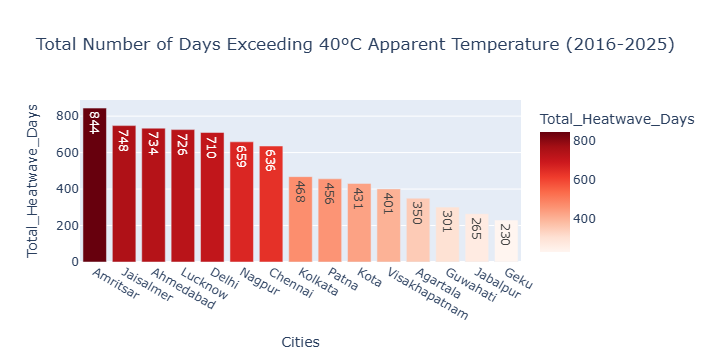

In [23]:
df['is_extreme_heat_feels_like'] = df['apparent_temperature_max'] > 40.0

heatwave_feels_counts = df.groupby('Cities')['is_extreme_heat_feels_like'].sum().reset_index()
heatwave_feels_counts.rename(columns={'is_extreme_heat_feels_like': 'Total_Heatwave_Days'}, inplace=True)

heatwave_counts_feels_like = heatwave_feels_counts.sort_values(by='Total_Heatwave_Days', ascending=False)
top_15_cities__feels_like_heatwave= heatwave_counts_feels_like.head(15)

fig = px.bar(
    top_15_cities__feels_like_heatwave[top_15_cities__feels_like_heatwave['Total_Heatwave_Days'] > 0],
    x='Cities', 
    y='Total_Heatwave_Days',
    title='Total Number of Days Exceeding 40°C Apparent Temperature (2016-2025)',
    color='Total_Heatwave_Days',
    color_continuous_scale='Reds',
    text_auto='.0f'
)
fig.show()

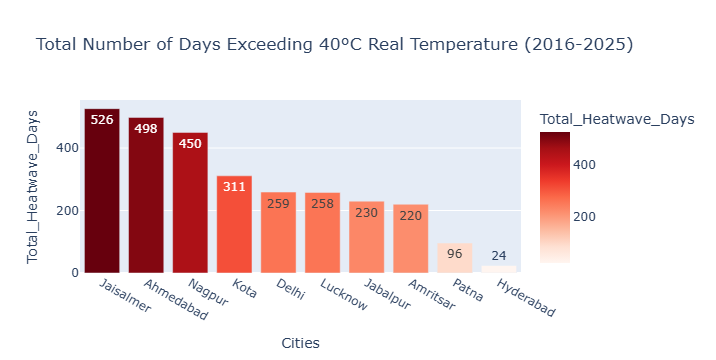

In [40]:
df['is_extreme_heat'] = df['temperature_2m_max'] > 40.0

heatwave_counts = df.groupby('Cities')['is_extreme_heat'].sum().reset_index()
heatwave_counts.rename(columns={'is_extreme_heat': 'Total_Heatwave_Days'}, inplace=True)

heatwave_counts = heatwave_counts.sort_values(by='Total_Heatwave_Days', ascending=False)
top_10_cities_heatwave= heatwave_counts.head(10)

fig = px.bar(
    top_10_cities_heatwave[top_10_cities_heatwave['Total_Heatwave_Days'] > 0],
    x='Cities', 
    y='Total_Heatwave_Days',
    title='Total Number of Days Exceeding 40°C Real Temperature (2016-2025)',
    color='Total_Heatwave_Days',
    color_continuous_scale='Reds',
    text_auto='.0f'
)
fig.show()

While analyzing **extreme heat**, a clear gap emerges between **dry-bulb temperature** *(actual air temperature)* and **apparent temperature** *(how hot it feels to the human body)*. In the **western plains (Lucknow, Delhi)**, the highest raw temperatures are driven by **dry, low-humidity “Loo” winds**; however, despite the intensity, the body can still cool itself through **effective sweating**, making conditions *relatively more tolerable*. In contrast, **eastern Gangetic cities (Patna, Kolkata)** often present **equal or greater danger** when assessed using apparent temperature, as **high humidity restricts sweat evaporation**, effectively **impairing the body’s primary cooling mechanism** and increasing **physiological stress**.  

> ⚠️ **Key Insight:** Heat risk is **not determined by temperature alone**—**humidity can make lower temperatures feel more dangerous than higher dry heat**.

## 🌧️Rainfall Analysis

### Year-wise Rainfall Trend Analysis Across Cities

In [41]:
city_avg.head()

0    1744.014286
1    1744.014286
2    1744.014286
3    1744.014286
4    1744.014286
Name: precipitation_sum, dtype: float64

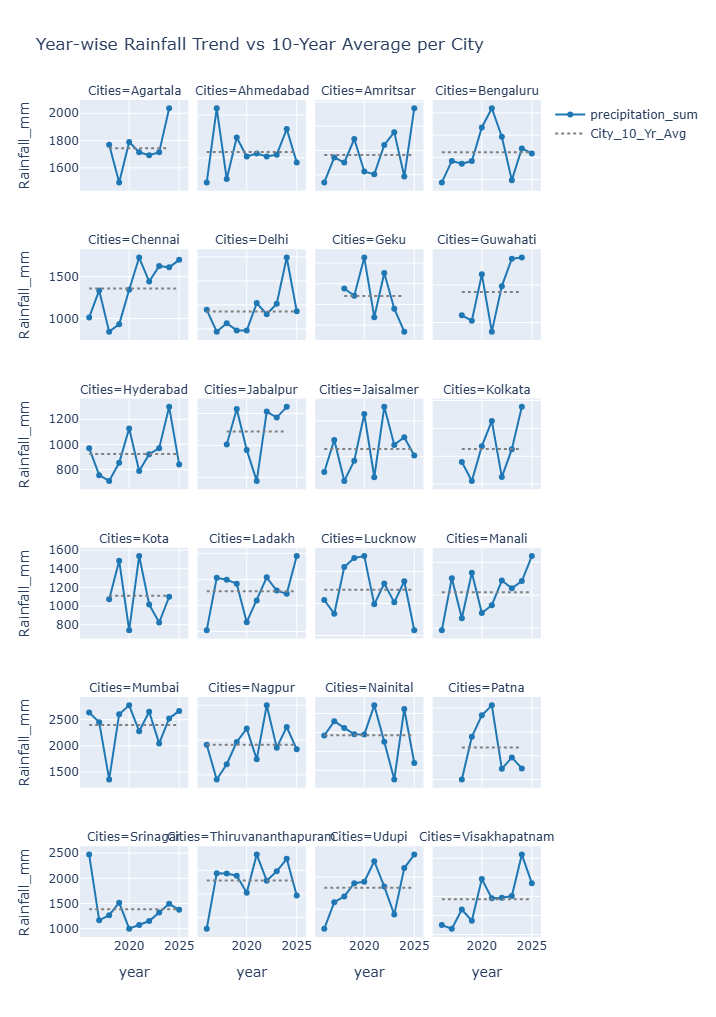

In [39]:
# 1. Calculate yearly total rainfall per city
yearly_rainfall = df.groupby(['Cities', 'year'])['precipitation_sum'].sum().reset_index()

# 2. Calculate the 10-year average rainfall for EACH city
city_avg = yearly_rainfall.groupby('Cities')['precipitation_sum'].transform('mean')
yearly_rainfall['City_10_Yr_Avg'] = city_avg

# 3. Melt the dataframe (Plotly Express needs long-format data to plot multiple lines easily)
df_plot = yearly_rainfall.melt(
    id_vars=['Cities', 'year'], 
    value_vars=['precipitation_sum', 'City_10_Yr_Avg'],
    var_name='Rainfall_Type', 
    value_name='Rainfall_mm'
)

# 4. Create the Facet Plot
fig = px.line(
    df_plot,
    x='year',
    y='Rainfall_mm',
    color='Rainfall_Type',         # Splits the data into two lines
    facet_col='Cities',            
    facet_col_wrap=4,              
    title='Year-wise Rainfall Trend vs 10-Year Average per City',
    color_discrete_map={
        'precipitation_sum': '#1f77b4',  # Standard Blue for actual rain
        'City_10_Yr_Avg': 'gray'         # Gray for the baseline average
    }
)

# 5. Styling to make the average line dotted and the actual rain have markers
# Update the actual rainfall line
fig.update_traces(mode='lines+markers', selector=dict(name='precipitation_sum'))
# Update the average line to be dotted with no markers
fig.update_traces(line=dict(dash='dot'), mode='lines', selector=dict(name='City_10_Yr_Avg'))

# 6. Improve spacing and readability
fig.update_layout(
    height=1000,           # Slightly taller to accommodate 24 subplots comfortably
    width=1200,
    showlegend=True,       # Keep legend so viewers know what the gray line is
    legend_title_text=''
)

# Optional: Free the Y-axes so flat-line cities (Jaisalmer) aren't squashed by wet cities (Guwahati)
fig.update_yaxes(matches=None) 

fig.show()

## 📊 Rainfall Change Ranking Across Cities

In [ ]:
# Assuming your pivot table is already created:
rainfall_pivot = yearly_rainfall.pivot(index='Cities', columns='year', values='precipitation_sum')

# 1. Calculate the average of the first 3 years (2016, 2017, 2018)
# We use .mean(axis=1) to get the average across those specific column years
first_3_years_avg = rainfall_pivot[[2016, 2017, 2018]].mean(axis=1)

# 2. Calculate the average of the last 3 years (2023, 2024, 2025)
last_3_years_avg = rainfall_pivot[[2023, 2024, 2025]].mean(axis=1)

# 3. Calculate the smoothed change
rainfall_pivot['True_Rainfall_Trend(mm)'] = last_3_years_avg - first_3_years_avg

# 4. Rank cities based on the stabilized trend
true_ranking = rainfall_pivot[['True_Rainfall_Trend(mm)']].sort_values(by='True_Rainfall_Trend(mm)', ascending=False)

print("Statistically Stabilized Rainfall Change (Last 3 Yrs Avg - First 3 Yrs Avg):")
true_ranking

### 🌧️ Rainfall Trends Analysis: Historical Validation & Insights

### 📈 Significant Increases in Rainfall

**Chennai (+580.5 mm)**  
A strong validation of the methodology. The year 2016 marked a severe drought in Tamil Nadu due to the complete failure of the Northeast monsoon. In contrast, the 2023–2025 period witnessed intense rainfall events, including the devastating Cyclone Michaung (December 2023). The sharp increase reflects the contrast between historically low averages and recent extreme precipitation.

**Manali (+513.0 mm)**  
Himachal Pradesh experienced unprecedented and catastrophic rainfall during the 2023 monsoon season. This anomaly is clearly captured in the recent 3-year dataset, highlighting a substantial upward trend.

**Udupi (+932.1 mm)**  
The western coast of India has seen a notable rise in extreme rainfall events, driven by rapid warming of the Arabian Sea. Given Udupi’s already high baseline (~3500 mm annually), an increase of over 900 mm represents a significant intensification of coastal monsoon activity.

---

### 📉 Notable Decreases in Rainfall

**Geku (-~760 mm)**  
The sharp decline aligns with reported rainfall deficits in parts of Arunachal Pradesh and the broader Northeast region, where precipitation patterns have become increasingly erratic.

**Srinagar & Nainital (Decreasing Trend)**  
Several Himalayan regions are experiencing long-term drying trends, characterized by reduced steady rainfall and more frequent dry spells. These shifts reflect changing climatic dynamics in mountainous ecosystems.

---

### 🌍 Key Climate Insights

- **Increasing Rainfall Regions:**  
  Cities like **Udupi, Guwahati, and Chennai** are experiencing stronger monsoon influence, leading to higher rainfall variability and increased flood risk.

- **Decreasing Rainfall Regions:**  
  Cities such as **Nainital, Srinagar, and Geku** are showing declining rainfall trends, indicating growing vulnerability to drought conditions.

---

### ⚖️ Conclusion

The data highlights a clear pattern of **uneven climate impacts across regions**. While some areas are facing intensified rainfall and flooding risks, others are becoming increasingly dry and vulnerable. This divergence underscores the growing complexity and regional disparity of climate change effects across India.

### 📊 Methodology Note
Rainfall varies greatly year to year, so comparing a single drought year (like 2016) with a single wet year (like 2025) can give misleading results.

Instead, we used:
- **Average of 2016–2018** (historical baseline)  
- **Average of 2023–2025** (recent period)

This approach reduces the impact of extreme years and provides a **more accurate and realistic trend**.

---

## 🌊 Rainfall vs Normal Rainfall Analysis
We will be using Indian Meteorological Department (IMD) percentage deviation standards to accurately classify historical flood and drought risks, filtering out minor year-over-year noise.

Official IMD classification for rainfall is as:
- **Excess (Flood Risk):** +20% or more above normal.
- **Normal:** Between -19% and +19%.
- **Deficient (Drought Risk):** -20% or less below normal.

In [26]:
#1. Calculate yearly total rainfall per city
yearly_rainfall = df.groupby(['Cities', 'year'])['precipitation_sum'].sum().reset_index()

# 2. Calculate NORMAL yearly rainfall 
normal_rainfall = yearly_rainfall.groupby('Cities')['precipitation_sum'].mean().reset_index()
normal_rainfall.rename(columns={'precipitation_sum': 'Normal_Rainfall'}, inplace=True)

# 3. Merge
rainfall_comparison = pd.merge(yearly_rainfall, normal_rainfall, on='Cities')

# 4. Calculate Percentage Deviation
rainfall_comparison['Deviation_%'] = ((rainfall_comparison['precipitation_sum'] - rainfall_comparison['Normal_Rainfall']) / rainfall_comparison['Normal_Rainfall']) * 100

# 5. IMD Standard Classification
def classify_imd_rainfall(dev):
    if dev >= 20:
        return 'Excess (Flood Risk)'
    elif dev <= -20:
        return 'Deficient (Drought Risk)'
    else:
        return 'Normal'

rainfall_comparison['Rainfall_Status'] = rainfall_comparison['Deviation_%'].apply(classify_imd_rainfall)

# Let's see how many of each category we have!
print(rainfall_comparison['Rainfall_Status'].value_counts())
display(rainfall_comparison.sample(10))

Rainfall_Status
Normal                      155
Deficient (Drought Risk)     36
Excess (Flood Risk)          28
Name: count, dtype: int64


,Cities,year,precipitation_sum,Normal_Rainfall,Deviation_%,Rainfall_Status
91,Jaisalmer,2019,177.0,242.960000,-27.148502,Deficient (Drought Risk)
12,Ahmedabad,2021,1050.1,1067.490000,-1.629055,Normal
170,Nainital,2024,2047.6,1770.700000,15.637883,Normal
197,Thiruvananthapuram,2024,2745.9,2286.410000,20.096571,Excess (Flood Risk)
124,Lucknow,2018,1228.3,1086.760000,13.024035,Normal
96,Jaisalmer,2024,308.8,242.960000,27.099111,Excess (Flood Risk)
128,Lucknow,2022,1125.0,1086.760000,3.518716,Normal
138,Manali,2022,2722.3,2542.890000,7.055358,Normal
108,Kota,2021,1535.7,1110.857143,38.244599,Excess (Flood Risk)
176,Patna,2022,1090.1,1270.185714,-14.177904,Normal


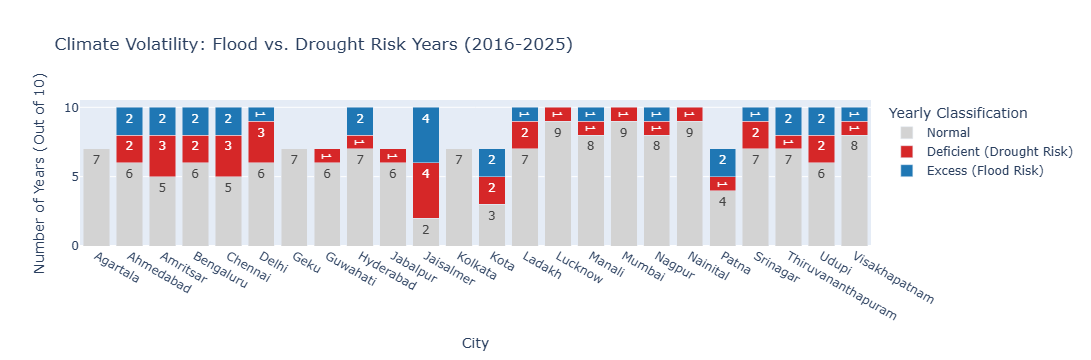

In [27]:
# 1. Count how many times each status occurred for each city over the 10 years
status_counts = rainfall_comparison.groupby(['Cities', 'Rainfall_Status']).size().reset_index(name='Number_of_Years')

# 2. Create a Stacked Bar Chart
fig = px.bar(
    status_counts,
    x='Cities',
    y='Number_of_Years',
    color='Rainfall_Status',
    title='Climate Volatility: Flood vs. Drought Risk Years (2016-2025)',
    color_discrete_map={
        'Excess (Flood Risk)': '#1f77b4',       # Dark Blue
        'Normal': '#d3d3d3',                    # Light Gray
        'Deficient (Drought Risk)': '#d62728'   # Red
    },
    text_auto=True
)

# 3. Clean up the layout
fig.update_layout(
    xaxis_title="City",
    yaxis_title="Number of Years (Out of 10)",
    barmode='stack', # Stacks the bars on top of each other
    legend_title_text='Yearly Classification'
)

fig.show()

**📌 Key Insights**

Jaisalmer exhibits high climate variability, with 8 out of 10 years classified as either flood or drought risk. Amritsar and Chennai also show notable variability, experiencing extreme conditions in roughly half of the observed years.

However, this classification reflects the frequency of extreme rainfall conditions rather than their intensity or direct impact.

Additionally, the dataset is incomplete—7 out of 24 cities are missing 3 years of data—resulting in 219 total years instead of 240, which should be considered when interpreting comparisons.

## 🌪️ Counting Storms 

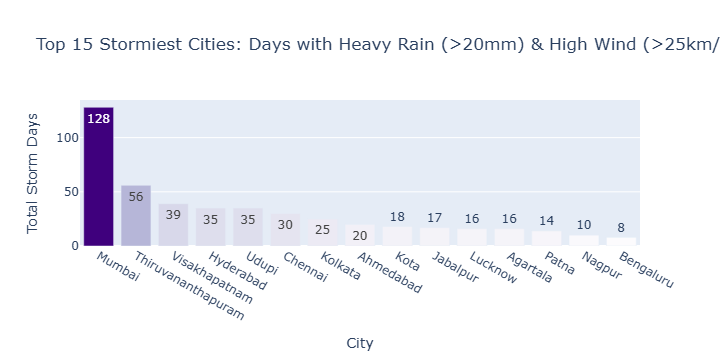

In [28]:
# 1. Define the Storm conditions (Wind > 25 km/h AND Rain > 20 mm)
df['is_storm'] = (df['wind_speed_10m_max'] > 25.0) & (df['precipitation_sum'] > 20.0)

# 2. Count total storm days per city over the 10 years
storm_counts = df.groupby('Cities')['is_storm'].sum().reset_index()
storm_counts.rename(columns={'is_storm': 'Total_Storm_Days'}, inplace=True)

# 3. Sort the cities from most storm days to least
storm_counts = storm_counts.sort_values(by='Total_Storm_Days', ascending=False)

# 4. Visualize the Top 15 Stormiest Cities
fig = px.bar(
    storm_counts[storm_counts['Total_Storm_Days'] > 0].head(15), # Filter to top 15 that had at least 1 storm
    x='Cities', 
    y='Total_Storm_Days',
    title='Top 15 Stormiest Cities: Days with Heavy Rain (>20mm) & High Wind (>25km/h) [2016-2025]',
    color='Total_Storm_Days',
    color_continuous_scale='Purples', # Purple feels stormy!
    text_auto='.0f'
)

# Clean up layout
fig.update_layout(
    coloraxis_showscale=False, 
    xaxis_title="City",
    yaxis_title="Total Storm Days"
)

# fig.update_traces(textfont_size=12, textangle=0, textposition="outside")

fig.show()

**📌 Key Insights**

The coastal cities like Mumbai, Thiruvananthapuram and Visakhapatnam see a high number of storms, i.e., high wind speed above 25km/h and heavy rainfall of >20mm on the same day. <br>
On the other hand, landlocked cities like Patna, Lucknow and Bangalore have fewer storms as the effect of cyclones reduces significantly as it reaches the inner cities while the effect is high on the coastal cities.

Though landlocked cities also experience a number of high speed winds `aandhi(dust storms)` in pre-monsoon preiod and a number of days with heavy rainfall. But here we mark a day as stormy if it has both, high wind speeds and heavy rainfall on the same day.

## ☀️ Solar Energy Potential

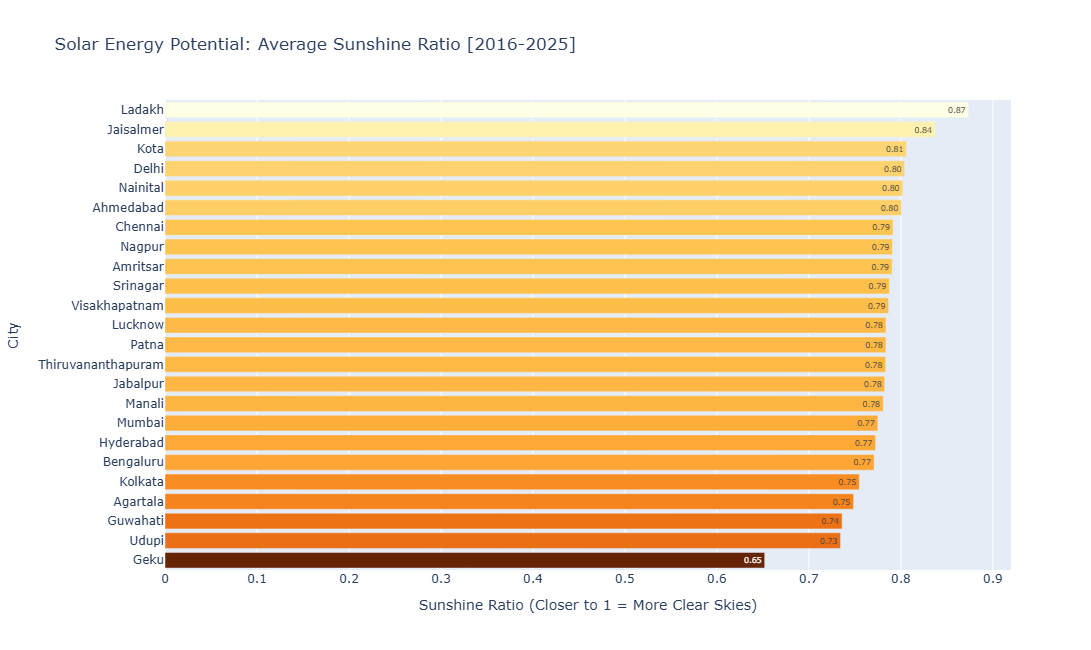

In [29]:
import plotly.express as px
import folium

# 1. Calculate Daily Sunshine Ratio
# (Since you already converted duration to hours, this will be a clean 0 to 1 ratio)
df['Sunshine_Ratio'] = df['sunshine_duration'] / df['daylight_duration']

# 2. Calculate the 10-year average Sunshine Ratio per city
solar_potential = df.groupby(['Cities', 'latitude', 'longitude'])['Sunshine_Ratio'].mean().reset_index()

# Sort for the bar chart (Ascending order looks better on horizontal charts)
solar_ranking = solar_potential.sort_values(by='Sunshine_Ratio', ascending=True)


fig = px.bar(
    solar_ranking,
    x='Sunshine_Ratio',
    y='Cities',
    orientation='h',
    title='Solar Energy Potential: Average Sunshine Ratio [2016-2025]',
    color='Sunshine_Ratio',
    color_continuous_scale='YlOrBr_r', # Yellow-Orange-Brown scale (_r for reversing the colour)
    text_auto='.2f'
)

fig.update_layout(
    height= 650,
    xaxis_title="Sunshine Ratio (Closer to 1 = More Clear Skies)",
    yaxis_title="City",
    coloraxis_showscale=False
)
fig.show()

In [30]:
from branca.element import Template, MacroElement

# 1. Initialize the map
solar_map = folium.Map(location=[22.0, 79.0], zoom_start=5, tiles='CartoDB dark_matter')

# 2. Add the city markers
for index, row in solar_potential.iterrows():
    ratio = row['Sunshine_Ratio']
    
    if ratio >= 0.80:
        color = '#FFEA00' # Gold (Excellent - Deserts and Dry Plains)
    elif ratio >= 0.75:
        color = '#FF8C00' # Orange (Good/Average)
    else:
        color = '#4682B4' # Steel Blue (Poor - Northeast/Heavy Monsoon zones)
        
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=10, 
        popup=f"<b>{row['Cities']}</b><br>Sunshine Ratio: {ratio:.2f}",
        tooltip=f"{row['Cities']} (Ratio: {ratio:.2f})",
        color=color,
        fill=True,
        fill_opacity=0.8
    ).add_to(solar_map)

# 3. Create Custom HTML for the Legend
legend_html = '''
{% macro html(this, kwargs) %}
<div style="
    position: fixed; 
    bottom: 50px; left: 50px; width: 170px; height: 110px; 
    border: 2px solid grey; z-index: 9999; font-size: 14px;
    background-color: rgba(255, 255, 255, 0.85); /* Semi-transparent white */
    padding: 10px;
    border-radius: 8px;
    font-family: Arial, sans-serif;
    ">
    <b style="margin-bottom: 5px; display: block;">Solar Potential</b>
    <i style="background: #FFEA00; width: 12px; height: 12px; float: left; margin-right: 8px; margin-top: 3px; border-radius: 50%;"></i> Excellent (&ge; 0.80)<br>
    <i style="background: #FF8C00; width: 12px; height: 12px; float: left; margin-right: 8px; margin-top: 3px; border-radius: 50%;"></i> Good (0.75 - 0.79)<br>
    <i style="background: #4682B4; width: 12px; height: 12px; float: left; margin-right: 8px; margin-top: 3px; border-radius: 50%;"></i> Poor (&lt; 0.75)
</div>
{% endmacro %}
'''

# 4. Attach the legend to the map
macro = MacroElement()
macro._template = Template(legend_html)
solar_map.get_root().add_child(macro)

# Display the map
solar_map

**📌 Key Insights**

Cities located near the Thar Desert show significantly higher sunlight duration, making them strong candidates for solar energy potential. In contrast, many other regions receive comparatively lower solar exposure.

Ladakh stands out as a unique case—despite being cold, it is extremely dry with minimal rainfall and clear skies throughout the year. This results in consistently high solar radiation and excellent solar energy potential.

On the other hand, cities in the Northeast experience heavy and frequent rainfall along with dense cloud cover, leading to much lower solar energy potential.

Overall, there is a clear inverse relationship between rainfall/cloud cover and solar energy availability across regions.

## 🗺️ Daylight Variation vs. Latitude

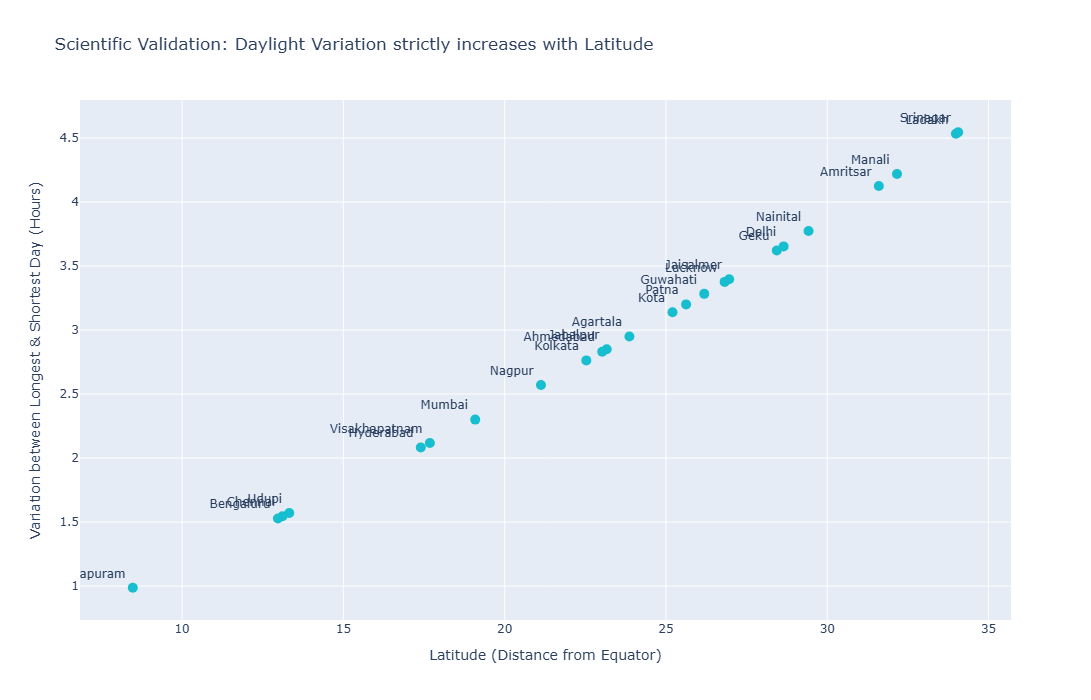

In [31]:
# 1. Find the longest and shortest day for each city
daylight_stats = df.groupby(['Cities', 'latitude'])['daylight_duration'].agg(['max', 'min']).reset_index()

# 2. Calculate the variation (Difference in hours)
daylight_stats['Daylight_Variation_Hours'] = daylight_stats['max'] - daylight_stats['min']

# 3. Plot the Scatter Plot
fig = px.scatter(
    daylight_stats,
    x='latitude',
    y='Daylight_Variation_Hours',
    text='Cities', # Show city names next to the dots
    title='Scientific Validation: Daylight Variation strictly increases with Latitude',
    labels={
        'latitude': 'Latitude (Distance from Equator)', 
        'Daylight_Variation_Hours': 'Variation between Longest & Shortest Day (Hours)'
    }
)

# 4. Clean up layout so text doesn't overlap too much
fig.update_traces(textposition='top left', marker=dict(size=10, color='#17BECF'))
fig.update_layout(height=700)

fig.show()

**📌 Key Insights**

The chart clearly shows a strong positive relationship between latitude and daylight variation. As cities are located farther from the equator, the difference between their longest and shortest days increases significantly.

Cities closer to the equator, such as Thiruvananthapuram and Udupi, experience minimal variation in daylight throughout the year, resulting in more consistent day lengths.

In contrast, cities at higher latitudes like Leh (Ladakh) and Srinagar show much larger variation, indicating longer summer days and shorter winter days.

This pattern aligns with Earth's axial tilt, where regions farther from the equator experience more pronounced seasonal changes in daylight duration.

## 🌾 Agriculture Suitability Analysis

In [34]:
monthly_agri

,Cities,month,precipitation_sum,et0_fao_evapotranspiration,Water_Balance
0,Agartala,1,0.216129,2.571429,-2.355300
1,Agartala,2,0.501010,3.356111,-2.855101
2,Agartala,3,1.645622,4.125115,-2.479493
3,Agartala,4,4.045714,4.616381,-0.570667
4,Agartala,5,8.463594,4.243641,4.219954
...,...,...,...,...,...
283,Visakhapatnam,8,8.166129,4.003000,4.163129
284,Visakhapatnam,9,9.747667,3.714267,6.033400
285,Visakhapatnam,10,5.356774,3.830871,1.525903
286,Visakhapatnam,11,2.286000,3.903267,-1.617267


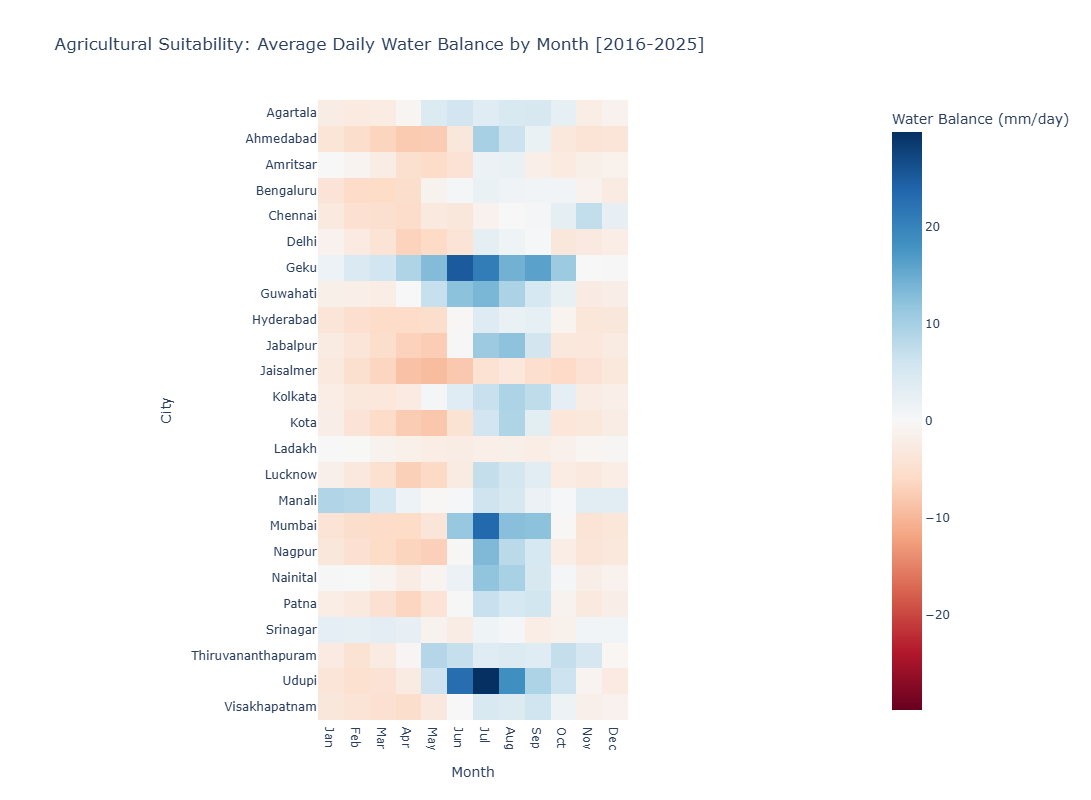

In [35]:
# 1. Calculate the daily average Rain and ET0 for each month, per city
monthly_agri = df.groupby(['Cities', 'month'])[['precipitation_sum', 'et0_fao_evapotranspiration']].mean().reset_index()

# 2. Calculate the Daily Water Balance
monthly_agri['Water_Balance'] = monthly_agri['precipitation_sum'] - monthly_agri['et0_fao_evapotranspiration']

# 3. Pivot the data to create a matrix for the Heatmap
# Rows = Cities, Columns = Months, Values = Water Balance
agri_pivot = monthly_agri.pivot(index='Cities', columns='month', values='Water_Balance')

# 4. Plot the Heatmap
fig = px.imshow(
    agri_pivot,
    labels=dict(x="Month", y="City", color="Water Balance (mm/day)"),
    x=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    title='Agricultural Suitability: Average Daily Water Balance by Month [2016-2025]',
    color_continuous_scale='RdBu',  # Red (Deficit) to Blue (Surplus)
    color_continuous_midpoint=0     # Sets the exact middle color (white) to 0 balance
)

fig.update_layout(
    height=800, 
    xaxis_title="Month", 
    yaxis_title="City"
)
fig.show()

**📌 Key Insights**

Based on the heatmap, several distinct agricultural climate patterns emerge across India:

- **🌾 The Kharif Window (Monsoon Dependency)**<br>
A prominent vertical blue band from **June to September** indicates a strong water surplus across most regions. This period defines the **Kharif season**, supporting water-intensive crops like paddy, driven by the Southwest Monsoon.

- **🌊 Extreme Coastal Surplus**<br>
Cities such as **Udupi, Mumbai, and Geku** show intense surplus (dark blue) during peak monsoon months (July–August). While beneficial for crop growth, this also signals a **high risk of water-logging and flood-related crop damage**.


- **🌵 The Rabi Deficit (Irrigation Dependency)**<br>
From **February to May**, many inland regions (e.g., Ahmedabad, Kota, Lucknow, Nagpur) shift into significant water deficit (orange/red). This highlights that **Rabi crops depend heavily on irrigation** due to high evapotranspiration and lack of rainfall.


- **🌧️ Northeast Monsoon Exception (Chennai)**<br>
**Chennai** follows a distinct pattern, receiving its main water surplus during **October to December** due to the Northeast Monsoon. This results in a **shifted agricultural calendar** compared to most of India.


- **🏜️ Arid Constraints (Jaisalmer)**<br>
**Jaisalmer** remains under persistent water deficit throughout the year, with only a slight relief in August. This confirms its **unsuitability for rain-fed agriculture**, requiring extensive irrigation support.


**⚖️ Overall Insight**<br>
India’s agricultural patterns are strongly governed by **monsoon timing, regional geography, and water balance**, leading to highly diverse farming dependencies across regions.

---

## 🛋️ The Livability & Climate Stability Score
To rank how "comfortable" a city is, we need to define a "Comfortable Day".

For the Indian climate, we can define a `comfortable day` using these strict but fair thresholds:

- **Temperature:** Maximum temperature between 18°C and 33°C (Not freezing, not sweating).
- **Humidity:** Mean humidity between 30% and 75% (Not overly dry, not oppressively muggy).
- **Rainfall:** Less than 5 mm (No heavy downpours ruining your plans).

We will score each city based on the percentage of its days that meet all three of these perfect conditions over the decade.

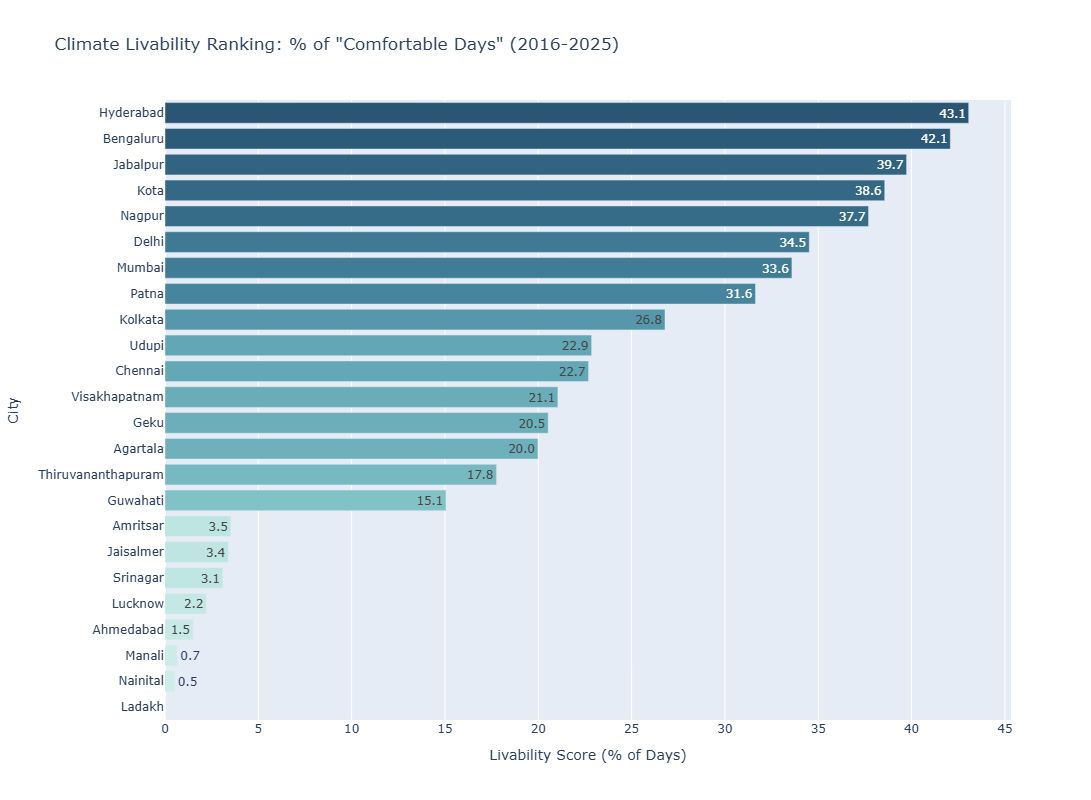

In [36]:
# 1. Define the criteria for a "Comfortable Day"
df['is_comfortable'] = (
    (df['temperature_2m_max'] >= 18.0) & (df['temperature_2m_max'] <= 33.0) &
    (df['relative_humidity_2m_mean'] >= 30.0) & (df['relative_humidity_2m_mean'] <= 75.0) &
    (df['precipitation_sum'] < 5.0)
)

# 2. Count comfortable days and total days per city
comfort_scores = df.groupby('Cities')['is_comfortable'].agg(['sum', 'count']).reset_index()
comfort_scores.rename(columns={'sum': 'Comfortable_Days', 'count': 'Total_Days'}, inplace=True)

# 3. Calculate Livability Score as a Percentage
comfort_scores['Livability_Score_%'] = (comfort_scores['Comfortable_Days'] / comfort_scores['Total_Days']) * 100

# 4. Sort cities (Ascending order is best for horizontal bar charts)
comfort_scores = comfort_scores.sort_values(by='Livability_Score_%', ascending=True)

# 5. Visualize the Rankings
fig = px.bar(
    comfort_scores,
    x='Livability_Score_%',
    y='Cities',
    orientation='h',
    title='Climate Livability Ranking: % of "Comfortable Days" (2016-2025)',
    color='Livability_Score_%',
    color_continuous_scale='Teal', # Teal is a nice, calming "comfortable" color
    text_auto='.1f'
)

# Clean up layout
fig.update_layout(
    height=800,
    xaxis_title="Livability Score (% of Days)",
    yaxis_title="City",
    coloraxis_showscale=False
)

fig.show()

**📌 Key Insights**

Based on a strict "Comfortable Day" threshold (Max Temp: 18°C–33°C, Humidity: 30%–75%, Rain < 5mm), the data reveals stark contrasts in urban climate stability across India:

* **The Deccan Plateau Advantage:** **Hyderabad (43.1%)** and **Bengaluru (42.1%)** emerge as the undeniable leaders in climate livability. Their high altitude on the Deccan Plateau naturally shields them from the oppressive coastal humidity and the scorching heatwaves of the northern plains, allowing them to remain in the "comfort zone" for nearly half the year.
* **Coastal Humidity Penalties:** Major economic hubs like **Mumbai (33.6%)** and **Chennai (22.7%)** rank in the middle tier. While their temperatures are relatively stable, they are heavily penalized by their coastal geography, where mean humidity frequently exceeds the 75% comfort ceiling for months at a time.
* **The Extremes (Mountains & Deserts):** Cities at the absolute bottom of the index failed due to geographical extremes. High-altitude cities like **Ladakh (0%)**, **Nainital (0.5%)**, and **Manali (0.7%)** rarely reach the 18°C maximum temperature baseline for most of the year. Similarly, **Ahmedabad (1.5%)** and **Jaisalmer (3.4%)** are penalized heavily by extreme summer heat (>40°C) and harsh, arid conditions where humidity drops below the 30% comfort floor. 

**Conclusion:** To maximize climate comfort and minimize reliance on artificial heating and cooling, the data strongly favors the inland, moderately elevated regions of Central and Southern India.

In [37]:
# df.to_csv('cleaned_weather_data', index=False)